In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [14]:
df = pd.read_csv("3_IMDB_dataset.csv")

print(df.head())
print(df.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


In [15]:
df['review'] = df['review'].str.replace('<br />', '', regex=False)

In [16]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [18]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [19]:
max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [20]:
model = keras.Sequential([
    keras.layers.Embedding(vocab_size, 32, input_length=max_len),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\Aditya.konde\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8071 - loss: 0.4266 - val_accuracy: 0.8775 - val_loss: 0.2951
Epoch 2/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8941 - loss: 0.2590 - val_accuracy: 0.8923 - val_loss: 0.2754
Epoch 3/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9112 - loss: 0.2230 - val_accuracy: 0.8785 - val_loss: 0.2945
Epoch 4/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9222 - loss: 0.2006 - val_accuracy: 0.8850 - val_loss: 0.2850
Epoch 5/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9296 - loss: 0.1838 - val_accuracy: 0.8827 - val_loss: 0.2962


In [23]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8847 - loss: 0.2884
Test Loss: 0.28844448924064636
Test Accuracy: 0.8847000002861023


In [24]:
predictions = model.predict(X_test_pad)
label_map = {1: "positive", 0: "negative"}

for i in range(5):
    pred_label = 1 if predictions[i] > 0.5 else 0
    
    print(
        "Actual:", label_map[y_test.iloc[i]],
        "Predicted:", label_map[pred_label]
    )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual: positive Predicted: negative
Actual: positive Predicted: positive
Actual: negative Predicted: negative
Actual: positive Predicted: positive
Actual: negative Predicted: negative


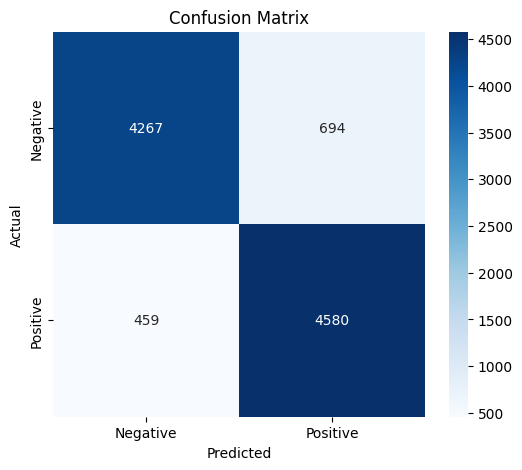

              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      4961
    Positive       0.87      0.91      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

pred_classes = (predictions > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print(classification_report(y_test, pred_classes, 
      target_names=['Negative', 'Positive']))